# FIR / TENT Explorer

**Goal.** Build intuition for what event spacing is required to recover a *full* HRF using TENT/FIR.
We've seen long TENT windows fail because the tail of one HRF gets contaminated by the next event's response.
Here we fix the TENT window long enough to capture full recovery (`TENT_TOP=30`) and sweep **mean ISI × max ISI** to map out where recovery is reliable.

Setup
- 3 event conditions, each with its own true HRF (from the canonical library) and a peak amplitude **in % signal change**.
- Data is in PSC-friendly units: baseline = 100, the per-onset response is peak-normalized so `amp` = peak %ΔBOLD.
- Poisson ISIs (truncated): `ISI = ISI_MIN + Exponential(mean = ISI_MEAN - ISI_MIN)`, clipped to `ISI_MAX`.
- Full simulation noise model: 1/f + respiratory + cardiac peaks (via `simulation.noise.generate_fmri_noise`) + scanner drift, scaled in % units.
- Batch of voxel realizations per cell so we get confidence bands on the recovered HRF.
- Fit TENT design via `design.matrices.make_tent_design`, GLM via `glm.core.fit_glm` (Legendre polynomials per run).

All knobs live in the first cell.

In [262]:
# ---------------- Parameters ----------------
TR = 1.0                       # seconds
RUN_DURATION = 240.0           # seconds per run
N_RUNS = 12                    # independent runs per simulation
N_VOXELS = 10                  # noise replicates inside one simulation
N_SIMS   = 20                  # independent simulations per sweep cell (own onsets + noise each)
                               # Total fits per cell = N_SIMS (each batches N_VOXELS in a single GLM).
                               # 25 cells × 10 sims is a few minutes on CPU. Start small if exploring.

# (hrf_library_idx, amplitude_PSC) -- one per condition; both vary independently.
# amplitude is the peak of the per-onset response in % signal change (baseline=100).
CONDITIONS = [
    (18,  3.0),   # condition A: 3.0% PSC peak
    (2, 1.5),   # condition B: 1.5% PSC peak
    (6, 1.0),   # condition C: 1.0% PSC peak
]
EVENT_DURATION = 3.0           # seconds (block of microtime ones to mimic 3 s stim)
BASELINE = 100.0               # raw baseline so PSC = (raw - 100) directly

# ISI distribution (truncated shifted-exponential, i.e. Poisson process with min/max).
# ISI is interpreted depending on EVENTS_NONOVERLAPPING:
#   - True  (default): ISI is the GAP between offset of one event and onset of the next,
#                      so events never overlap (onset-to-onset >= EVENT_DURATION + ISI_MIN).
#                      Events are pooled across conditions, so no two condition blocks overlap either.
#   - False: ISI is onset-to-onset interval; with ISI < EVENT_DURATION events overlap in time.
EVENTS_NONOVERLAPPING = True
ISI_MIN  = 1.0                 # fixed for all sweeps (gap, when nonoverlapping)
ISI_MEAN = 2.0                 # baseline for the single-config sanity plot
ISI_MAX  = 7.0                 # baseline for the single-config sanity plot

# TENT estimation window — fixed; we want full recovery, so 30 s should always be enough
TENT_BOT = 0.0
TENT_TOP = 30.0
TENT_DT  = 1.0                 # knot spacing (s); n_basis = round((top-bot)/dt)+1
TENT_ZERO_EDGES = False        # AFNI TENTzero=False keeps endpoints free

# Noise — in PSC units. NOISE_PSC=0.5 means ~0.5% PSC std per timepoint after the 1/f+phys spectrum.
NOISE_PSC        = 0.5
DRIFT_PSC        = 0.4         # low-freq drift amplitude in % units
RESP_STRENGTH    = 3.0
CARDIAC_STRENGTH = 5.0
PINK_EXP         = 1.0

# Drift modeling in GLM
POLY_DEG = 2                   # per-run Legendre polynomials (CLAUDE.md: never 0 with nuisance designs)

TRUE_HRF_DUR = 32.0            # window for the canonical library HRFs

# Sweeps for the 2-D map -- 5 mean ISIs × 5 max ISIs (interpreted per EVENTS_NONOVERLAPPING)
SWEEP_ISI_MEANS = [2.0, 2.5, 3.0, 4.0, 5.0]
SWEEP_ISI_MAXES = [3.0, 4.0, 5.0, 8.0, 10.0]

SEED = 7
DEVICE = 'cpu'

import numpy as np, torch, matplotlib.pyplot as plt
from fastfuncstuff.design.hrf import load_canonical_hrf_library
from fastfuncstuff.design.matrices import make_tent_design
from fastfuncstuff.simulation.noise import generate_fmri_noise, add_drift
from fastfuncstuff.glm.core import fit_glm

torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device(DEVICE)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')
if EVENTS_NONOVERLAPPING:
    print(f'  ISI = gap between events. Min onset-to-onset = EVENT_DURATION + ISI_MIN = {EVENT_DURATION + ISI_MIN:g}s')
else:
    print(f'  ISI = onset-to-onset. Events may overlap if ISI_MIN < EVENT_DURATION ({EVENT_DURATION:g}s).')

Ready.
  ISI = gap between events. Min onset-to-onset = EVENT_DURATION + ISI_MIN = 4s


## 1. True HRFs and per-onset *effective* response

TENT/FIR estimate the response **per onset**, not per microtime impulse. With a 3-s stim block the per-onset response is `(block ⊛ HRF)`, which has a peak much greater than the raw HRF peak. To make `amp` directly = peak PSC, we **peak-normalize the block-convolved response** for each condition; that's what TENT will recover (×`amp`).

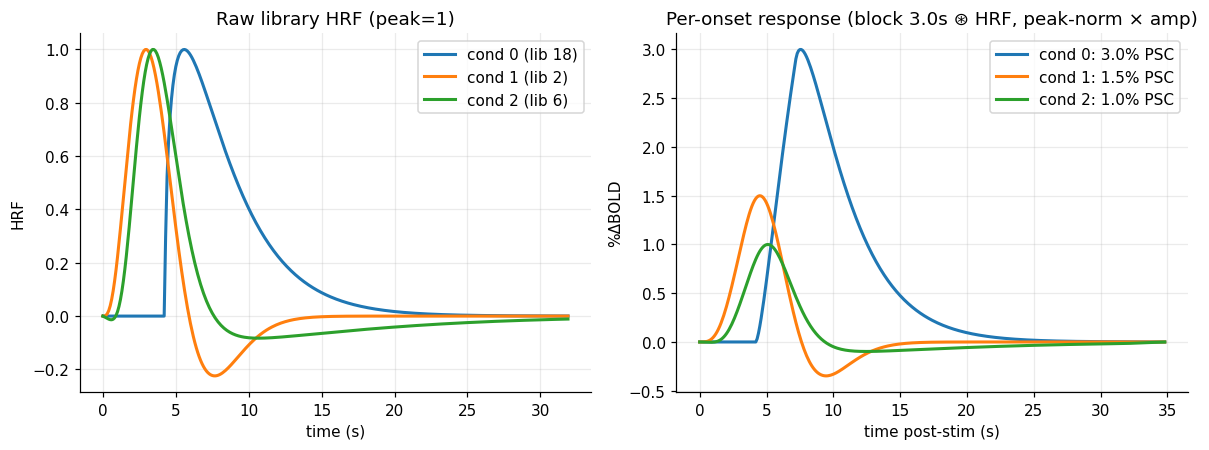

In [263]:
MICRO_DT = 0.1
hrf_lib_hi = load_canonical_hrf_library(microtime_dt=MICRO_DT, hrf_duration=TRUE_HRF_DUR, device=device).cpu().numpy()
t_hrf_hi = np.arange(hrf_lib_hi.shape[1]) * MICRO_DT

block_len_micro = int(round(EVENT_DURATION / MICRO_DT))
stim_block = np.ones(block_len_micro, dtype=np.float32)
n_eff_hi = hrf_lib_hi.shape[1] + block_len_micro - 1
t_eff_hi = np.arange(n_eff_hi) * MICRO_DT

true_idx     = [idx for idx, _amp in CONDITIONS]
amps         = np.array([a for _i, a in CONDITIONS], dtype=np.float32)
n_cond       = len(CONDITIONS)
true_hrfs_hi = np.stack([hrf_lib_hi[i] for i in true_idx])

eff_resp_hi = np.stack([np.convolve(stim_block, true_hrfs_hi[c]) for c in range(n_cond)])
eff_peaks   = eff_resp_hi.max(axis=1)
eff_resp_hi = eff_resp_hi / eff_peaks[:, None]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for c, (idx, amp) in enumerate(CONDITIONS):
    ax[0].plot(t_hrf_hi, true_hrfs_hi[c], lw=2.0, label=f'cond {c} (lib {idx})')
    ax[1].plot(t_eff_hi, amp * eff_resp_hi[c], lw=2.0, label=f'cond {c}: {amp:.1f}% PSC')
ax[0].set(title='Raw library HRF (peak=1)', xlabel='time (s)', ylabel='HRF')
ax[1].set(title=f'Per-onset response (block {EVENT_DURATION}s ⊛ HRF, peak-norm × amp)',
          xlabel='time post-stim (s)', ylabel='%ΔBOLD')
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()

## 2. Onset generator (truncated Poisson ISI)

Per condition we draw onsets independently. The condition label for each event is round-robin'd across draws to keep counts balanced; ISIs are pooled across conditions so increasing `mean_isi` increases the *gap to the next event of any kind*, which is what determines tail contamination.

In [264]:
def make_onsets_one_run(rng, run_dur, isi_min, isi_max, isi_mean, n_cond,
                        nonoverlapping=EVENTS_NONOVERLAPPING, event_dur=EVENT_DURATION,
                        tr=TR, hrf_pad=TRUE_HRF_DUR):
    """Return list of length n_cond, each an np.ndarray of onset times (s).

    ISIs are drawn from a shifted exponential then **rounded to the nearest TR multiple**
    and clipped to [isi_min, isi_max]. With TR=1, isi_min=1, isi_max=7 the gap takes
    integer values in {1,2,3,4,5,6,7}.

    If nonoverlapping=True, ISI is the offset->onset gap; otherwise onset-to-onset.
    """
    scale = max(isi_mean - isi_min, 1e-6)
    times, labels = [], []
    t = rng.uniform(2.0, max(2.0, isi_min + 1.0))
    # snap initial onset to TR grid for tidiness
    t = round(t / tr) * tr
    k = 0
    while t < run_dur - hrf_pad - 2.0:
        times.append(t)
        labels.append(k % n_cond)
        k += 1
        gap = isi_min + rng.exponential(scale)
        gap = round(gap / tr) * tr        # TR-quantize
        gap = max(isi_min, min(gap, isi_max))
        if nonoverlapping:
            t += event_dur + gap
        else:
            t += gap
    times = np.array(times); labels = np.array(labels)
    perm = rng.permutation(len(labels))
    labels = labels[perm]
    return [np.sort(times[labels == c]) for c in range(n_cond)]

_rng = np.random.default_rng(SEED)
_demo = make_onsets_one_run(_rng, RUN_DURATION, ISI_MIN, ISI_MAX, ISI_MEAN, n_cond)
for c, ons in enumerate(_demo):
    print(f'cond {c}: {len(ons)} events, first few = {np.round(ons[:5], 2)}')

all_t = np.sort(np.concatenate(_demo))
if len(all_t) > 1:
    diffs = np.diff(all_t)
    unique_gaps, counts = np.unique(np.round(diffs, 3), return_counts=True)
    print(f'  min onset-to-onset across all conds: {diffs.min():.2f}s '
          f'(expected >= {EVENT_DURATION + ISI_MIN if EVENTS_NONOVERLAPPING else ISI_MIN:g}s)')
    print(f'  observed gap histogram (s : count): '
          f'{dict(zip(unique_gaps.tolist(), counts.tolist()))}')

cond 0: 14 events, first few = [ 2. 21. 39. 62. 67.]
cond 1: 14 events, first few = [ 7. 12. 32. 44. 48.]
cond 2: 13 events, first few = [17. 28. 53. 57. 77.]
  min onset-to-onset across all conds: 4.00s (expected >= 4s)
  observed gap histogram (s : count): {4.0: 14, 5.0: 19, 6.0: 2, 7.0: 4, 8.0: 1}


## 3. Build clean signal (PSC units), add full noise model

For each condition the per-onset effective response is peak-normalized then scaled by `amp`. We sum onsets at microtime resolution (handles overlap exactly) and resample to TR. Final data = `BASELINE + signal_PSC + noise_PSC`.

In [265]:
def build_clean_signal(onsets_per_cond, run_dur, tr, eff_resp_hi, amps, micro_dt=MICRO_DT):
    """Return (n_tp,) clean BOLD signal in PSC units (no baseline added here)."""
    n_tp = int(round(run_dur / tr))
    n_micro = int(round(run_dur / micro_dt))
    sig_micro = np.zeros(n_micro, dtype=np.float32)
    for c, onsets in enumerate(onsets_per_cond):
        kernel = amps[c] * eff_resp_hi[c]
        klen = kernel.shape[0]
        for ons in onsets:
            i0 = int(round(ons / micro_dt))
            i1 = min(n_micro, i0 + klen)
            sig_micro[i0:i1] += kernel[: i1 - i0]
    idx = np.round(np.arange(n_tp) * tr / micro_dt).astype(int)
    idx = np.clip(idx, 0, n_micro - 1)
    return sig_micro[idx]

def make_noise_batch(n_voxels, n_tp, tr, scale_psc, drift_psc, seed_offset=0):
    """(n_voxels, n_tp) noise in PSC units = unit-var phys noise * scale + low-freq drift.

    NOTE: simulation.noise.add_drift expects time on axis 0; we transpose around the call.
    Otherwise with small n_voxels it treats voxels as time, std over a tiny axis ~ 0,
    and the amplitude/std rescale blows up.
    """
    torch.manual_seed(SEED + seed_offset)
    noise = generate_fmri_noise(
        tr=tr, duration_s=n_tp * tr, matrix_size=(n_voxels, 1),
        resp_strength=RESP_STRENGTH, cardiac_strength=CARDIAC_STRENGTH, pink_exp=PINK_EXP,
        normalize=True, device=device,
    ).reshape(n_tp, n_voxels)            # (n_tp, n_voxels) -- time first
    noise = noise * scale_psc
    noise = add_drift(noise, amplitude=drift_psc, n_modes=3, device=device)  # axis 0 = time
    return noise.T                       # back to (n_voxels, n_tp)

## 4. Build TENT design and fit

Per-condition TENT basis built separately and `hstack`ed so beta columns are `[cond0_lag0, …, cond0_lagK, cond1_lag0, …]`. Per-run designs and per-run data are passed as lists to `fit_glm`, which adds Legendre polynomials per run (`max_poly_degree=POLY_DEG`).

Because data is in PSC-friendly units (baseline=100, signal in % units), the polynomial regressors absorb the constant 100 mean and the recovered task betas come out directly in % signal change — i.e. comparable to the `amps` we set.

In [266]:
def build_tent_design_per_cond(onsets_per_cond, tent_bot, tent_top, tent_dt, tr, n_tp):
    n_basis = int(round((tent_top - tent_bot) / tent_dt)) + 1
    blocks = []
    for ons in onsets_per_cond:
        d_c = make_tent_design(
            [ons], bot=tent_bot, top=tent_top, tr=tr, n_timepoints=n_tp,
            n_basis=n_basis, zero_edges=TENT_ZERO_EDGES, device=device,
        )
        blocks.append(d_c)
    return torch.cat(blocks, dim=1), n_basis

def fit_one_config(isi_mean, isi_max, n_runs=N_RUNS, n_voxels=N_VOXELS, seed_offset=0,
                   tent_top=TENT_TOP, return_first_run=False, verbose=False):
    rng = np.random.default_rng(SEED + 1000 + seed_offset)
    n_tp = int(round(RUN_DURATION / TR))
    data_per_run, design_per_run, onsets_all = [], [], []
    clean_run0 = noise_run0 = None
    for r in range(n_runs):
        onsets_per_cond = make_onsets_one_run(rng, RUN_DURATION, ISI_MIN, isi_max, isi_mean, n_cond)
        onsets_all.append(onsets_per_cond)
        clean_psc = build_clean_signal(onsets_per_cond, RUN_DURATION, TR, eff_resp_hi, amps)
        clean_t = torch.from_numpy(clean_psc).to(device).float()
        noise = make_noise_batch(n_voxels, n_tp, TR, NOISE_PSC, DRIFT_PSC, seed_offset=10*r + seed_offset)
        data = BASELINE + clean_t.unsqueeze(0) + noise
        design, n_basis = build_tent_design_per_cond(onsets_per_cond, TENT_BOT, tent_top, TENT_DT, TR, n_tp)
        data_per_run.append(data)
        design_per_run.append(design)
        if r == 0:
            clean_run0 = clean_psc
            noise_run0 = noise.cpu().numpy()
    res = fit_glm(
        data=data_per_run, design=design_per_run, tr=TR,
        max_poly_degree=POLY_DEG, want_r2_run=False, want_predicted=return_first_run,
        device=device, verbose=verbose,
    )
    betas = res.betas.cpu().numpy()
    n_task = n_cond * n_basis
    task_betas = betas[:, :n_task].reshape(n_voxels, n_cond, n_basis)
    knot_times = TENT_BOT + np.arange(n_basis) * TENT_DT
    out = dict(task_betas=task_betas, knot_times=knot_times, n_basis=n_basis,
               onsets_all=onsets_all, isi_mean=isi_mean, isi_max=isi_max)
    if return_first_run:
        # res.predicted may be: list per run, or a single tensor with runs concatenated.
        if isinstance(res.predicted, list):
            pred_run0 = res.predicted[0].cpu().numpy()
        else:
            pred_full = res.predicted.cpu().numpy()
            # find the time axis (one of its dims will be n_runs*n_tp or n_tp)
            shape = pred_full.shape
            if n_runs * n_tp in shape:
                time_axis = shape.index(n_runs * n_tp)
                pred_run0 = np.take(pred_full, range(n_tp), axis=time_axis)
            elif n_tp in shape:
                pred_run0 = pred_full  # already per-run somehow
            else:
                raise RuntimeError(f"can't find time axis in predicted shape {shape}")
        # ensure shape is (n_voxels, n_tp)
        if pred_run0.shape[0] == n_tp and pred_run0.ndim == 2:
            pred_run0 = pred_run0.T
        out.update(clean_run0=clean_run0, noise_run0=noise_run0,
                   data_run0=(BASELINE + clean_run0[None, :] + noise_run0),
                   pred_run0=pred_run0, onsets_run0=onsets_all[0])
    return out

## 5. Sanity check + voxel timecourse view

Single config at the baseline `ISI_MEAN` / `ISI_MAX`. Top panel: one voxel's full data with the GLM's predicted timecourse and the noiseless ground-truth signal overlaid, plus event onset ticks colored by condition. Below: recovered TENT HRFs vs truth (one panel per condition).

Fitting GLM: 10 voxels, 12 runs, 93 task regressors
Processing in chunks of 10 voxels


Processing voxel chunks:   0%|          | 0/1 [00:00<?, ?chunk/s]

GLM complete. Mean R² = 0.927
Run 0 sanity:  events=41  clean signal peak=5.15% PSC, mean=1.46%  noise std=0.52%


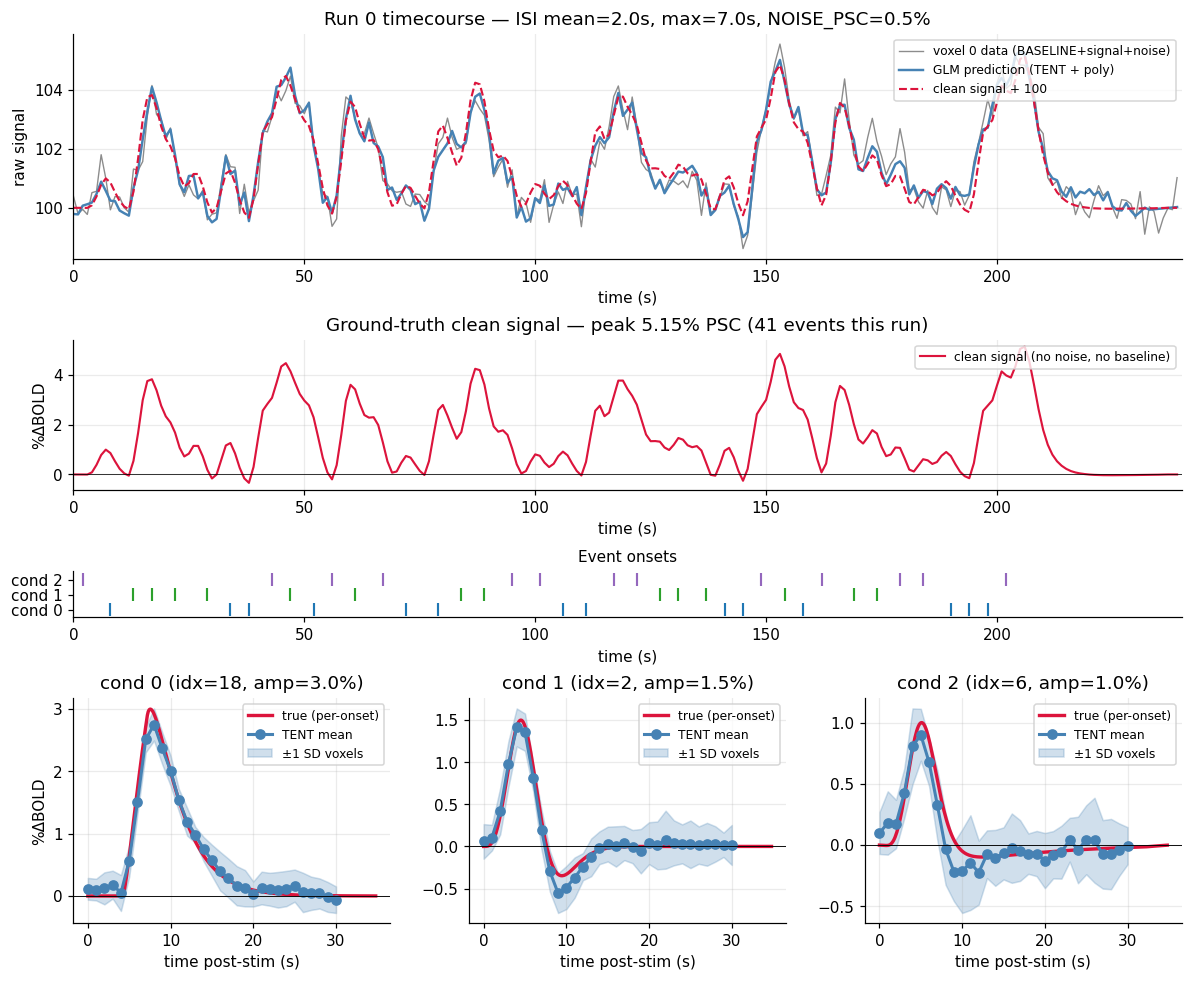

In [267]:
demo = fit_one_config(ISI_MEAN, ISI_MAX, return_first_run=True, verbose=True)
kt = demo['knot_times']; tb = demo['task_betas']
mean_b = tb.mean(0); sd_b = tb.std(0)

n_tp = int(round(RUN_DURATION / TR))
t_ax = np.arange(n_tp) * TR
v_idx = 0
data_v   = demo['data_run0'][v_idx]               # raw (with baseline + signal + noise)
pred_v   = demo['pred_run0'][v_idx]               # GLM prediction (raw units)
clean_psc = demo['clean_run0']                    # ground-truth signal in PSC (no baseline)
noise_psc = demo['noise_run0'][v_idx]             # noise in PSC for this voxel
n_events_total = sum(len(o) for o in demo['onsets_run0'])

print(f"Run 0 sanity:  events={n_events_total}  "
      f"clean signal peak={clean_psc.max():.2f}% PSC, mean={clean_psc.mean():.2f}%  "
      f"noise std={noise_psc.std():.2f}%")

cond_colors = ['#1f77b4', '#2ca02c', '#9467bd']
fig = plt.figure(figsize=(13, 10.5))
gs  = fig.add_gridspec(4, n_cond, height_ratios=[2.4, 1.6, 0.5, 2.4], hspace=0.5, wspace=0.25)

# row 0: raw data + GLM prediction + ground-truth signal lifted to baseline
ax_tc = fig.add_subplot(gs[0, :])
ax_tc.plot(t_ax, data_v, color='0.55', lw=0.9, label=f'voxel {v_idx} data (BASELINE+signal+noise)')
ax_tc.plot(t_ax, pred_v, color='steelblue', lw=1.6, label='GLM prediction (TENT + poly)')
ax_tc.plot(t_ax, BASELINE + clean_psc, color='crimson', lw=1.4, ls='--', label='clean signal + 100')
ax_tc.set(xlabel='time (s)', ylabel='raw signal', xlim=(0, RUN_DURATION),
          title=f'Run 0 timecourse — ISI mean={ISI_MEAN}s, max={ISI_MAX}s, NOISE_PSC={NOISE_PSC}%')
ax_tc.legend(loc='upper right', fontsize=8)

# row 1: clean signal alone (PSC, no baseline) — visible regardless of noise scale
ax_clean = fig.add_subplot(gs[1, :], sharex=ax_tc)
ax_clean.plot(t_ax, clean_psc, color='crimson', lw=1.4, label='clean signal (no noise, no baseline)')
ax_clean.axhline(0, color='k', lw=0.5)
ax_clean.set(ylabel='%ΔBOLD', xlabel='time (s)',
             title=f'Ground-truth clean signal — peak {clean_psc.max():.2f}% PSC '
                   f'({n_events_total} events this run)')
ax_clean.legend(loc='upper right', fontsize=8)

# row 2: event onsets per condition
ax_ev = fig.add_subplot(gs[2, :], sharex=ax_tc)
for c, ons in enumerate(demo['onsets_run0']):
    ax_ev.vlines(ons, c, c + 0.85, color=cond_colors[c], lw=1.4)
ax_ev.set(yticks=[i + 0.4 for i in range(n_cond)], yticklabels=[f'cond {i}' for i in range(n_cond)],
          ylim=(-0.1, n_cond), xlabel='time (s)')
ax_ev.set_title('Event onsets', fontsize=10)
ax_ev.grid(False)

# row 3: recovered HRF per condition
for c in range(n_cond):
    ax = fig.add_subplot(gs[3, c])
    ax.plot(t_eff_hi, amps[c] * eff_resp_hi[c], color='crimson', lw=2.2, label='true (per-onset)')
    ax.plot(kt, mean_b[c], 'o-', color='steelblue', lw=2, label='TENT mean')
    ax.fill_between(kt, mean_b[c] - sd_b[c], mean_b[c] + sd_b[c], alpha=0.25, color='steelblue', label='±1 SD voxels')
    ax.axhline(0, color='k', lw=0.6)
    ax.set(title=f'cond {c} (idx={CONDITIONS[c][0]}, amp={CONDITIONS[c][1]}%)',
           xlabel='time post-stim (s)')
    if c == 0:
        ax.set_ylabel('%ΔBOLD')
    ax.legend(fontsize=8)
plt.show()

## 6. The 2-D sweep: mean ISI × max ISI

TENT window is fixed at `TENT_TOP=30 s`. For each `(isi_mean, isi_max)` cell we run a fresh experiment and store the recovered HRFs. RMSE is computed against the per-onset effective response interpolated to knot times — i.e. against the truth in PSC units.

In [268]:
def count_events(onsets_all):
    """Return total events per condition (summed across runs) and per-run total."""
    n_cond_local = len(onsets_all[0])
    per_cond = np.zeros(n_cond_local, dtype=int)
    per_run_totals = []
    for run_onsets in onsets_all:
        run_total = 0
        for c in range(n_cond_local):
            per_cond[c] += len(run_onsets[c])
            run_total += len(run_onsets[c])
        per_run_totals.append(run_total)
    return per_cond, per_run_totals

# results_grid[(i,j)] = dict with stacked arrays across N_SIMS independent simulations.
# Each sim draws fresh onsets AND fresh noise; within a sim, N_VOXELS share the onsets.
# We summarise each sim by its mean recovered HRF (mean across voxels) and per-cond RMSE.
results_grid = {}
status_grid  = np.full((len(SWEEP_ISI_MEANS), len(SWEEP_ISI_MAXES)), '         ', dtype='<U10')

# Aggregate stats for heatmaps
rmse_median = np.full((len(SWEEP_ISI_MEANS), len(SWEEP_ISI_MAXES)), np.nan)
rmse_iqr    = np.full_like(rmse_median, np.nan)
nev_mean    = np.full_like(rmse_median, np.nan)

for i, isi_m in enumerate(SWEEP_ISI_MEANS):
    for j, isi_x in enumerate(SWEEP_ISI_MAXES):
        if isi_x < isi_m + 0.5:
            status_grid[i, j] = 'max<mean'
            print(f'  skip ISI mean={isi_m}, max={isi_x} (max < mean)')
            continue
        per_sim_mean_b   = []      # list of (n_cond, n_basis) -- mean across voxels for that sim
        per_sim_rmse_sum = []      # list of scalar -- sum-cond RMSE for that sim
        per_sim_rmse_per = []      # list of (n_cond,)
        per_sim_events_total = []  # list of int (total events, all runs+conds)
        per_sim_onsets_all   = []  # nested for ISI hist later
        any_sim_ok = False
        for s in range(N_SIMS):
            try:
                out = fit_one_config(isi_m, isi_x, seed_offset=10000 * s + i * 100 + j, verbose=False)
            except (UnboundLocalError, RuntimeError, torch.linalg.LinAlgError) as e:
                if not any_sim_ok and s == 0:
                    status_grid[i, j] = 'singular'
                    print(f'  ISI mean={isi_m:5.1f}s  max={isi_x:5.1f}s  sim {s} FAILED: {type(e).__name__}: {e}')
                continue
            kt = out['knot_times']
            mean_b = out['task_betas'].mean(0)               # (n_cond, n_basis)
            truth_at_knots = np.stack([
                amps[c] * np.interp(kt, t_eff_hi, eff_resp_hi[c]) for c in range(n_cond)
            ])
            rmse_per = np.sqrt(((mean_b - truth_at_knots) ** 2).mean(axis=1))
            per_sim_mean_b.append(mean_b)
            per_sim_rmse_sum.append(rmse_per.sum())
            per_sim_rmse_per.append(rmse_per)
            per_cond, per_run = count_events(out['onsets_all'])
            per_sim_events_total.append(int(per_cond.sum()))
            per_sim_onsets_all.append(out['onsets_all'])
            any_sim_ok = True
        if not any_sim_ok:
            continue
        per_sim_mean_b   = np.stack(per_sim_mean_b)              # (n_sims_ok, n_cond, n_basis)
        per_sim_rmse_sum = np.array(per_sim_rmse_sum)            # (n_sims_ok,)
        per_sim_rmse_per = np.stack(per_sim_rmse_per)            # (n_sims_ok, n_cond)
        per_sim_events_total = np.array(per_sim_events_total)
        results_grid[(i, j)] = dict(
            knot_times=kt, truth_at_knots=truth_at_knots,
            per_sim_mean_b=per_sim_mean_b,
            per_sim_rmse_sum=per_sim_rmse_sum,
            per_sim_rmse_per=per_sim_rmse_per,
            per_sim_events_total=per_sim_events_total,
            per_sim_onsets_all=per_sim_onsets_all,
            isi_mean=isi_m, isi_max=isi_x, n_sims_ok=len(per_sim_rmse_sum),
        )
        rmse_median[i, j] = np.median(per_sim_rmse_sum)
        rmse_iqr[i, j]    = np.percentile(per_sim_rmse_sum, 75) - np.percentile(per_sim_rmse_sum, 25)
        nev_mean[i, j]    = per_sim_events_total.mean() / N_RUNS  # avg events per run
        status_grid[i, j] = 'ok'
        print(f'  ISI mean={isi_m:5.1f}s  max={isi_x:5.1f}s  '
              f'sims={len(per_sim_rmse_sum)}/{N_SIMS}  '
              f'RMSE median={rmse_median[i, j]:.3f}%  IQR={rmse_iqr[i, j]:.3f}%  '
              f'ev/run={nev_mean[i, j]:.1f}')

  ISI mean=  2.0s  max=  3.0s  sims=20/20  RMSE median=0.253%  IQR=0.074%  ev/run=42.6
  ISI mean=  2.0s  max=  4.0s  sims=20/20  RMSE median=0.214%  IQR=0.052%  ev/run=42.0
  ISI mean=  2.0s  max=  5.0s  sims=20/20  RMSE median=0.265%  IQR=0.061%  ev/run=41.8
  ISI mean=  2.0s  max=  8.0s  sims=20/20  RMSE median=0.249%  IQR=0.057%  ev/run=41.6
  ISI mean=  2.0s  max= 10.0s  sims=20/20  RMSE median=0.269%  IQR=0.081%  ev/run=41.5
  ISI mean=  2.5s  max=  3.0s  sims=20/20  RMSE median=0.285%  IQR=0.071%  ev/run=40.5
  ISI mean=  2.5s  max=  4.0s  sims=20/20  RMSE median=0.245%  IQR=0.064%  ev/run=39.0
  ISI mean=  2.5s  max=  5.0s  sims=20/20  RMSE median=0.254%  IQR=0.072%  ev/run=38.4
  ISI mean=  2.5s  max=  8.0s  sims=20/20  RMSE median=0.242%  IQR=0.038%  ev/run=37.8
  ISI mean=  2.5s  max= 10.0s  sims=20/20  RMSE median=0.218%  IQR=0.071%  ev/run=37.6
  skip ISI mean=3.0, max=3.0 (max < mean)
  ISI mean=  3.0s  max=  4.0s  sims=20/20  RMSE median=0.239%  IQR=0.097%  ev/run=37.3
 

## 7. Visualise recovery across the grid

Each subplot shows recovered HRFs (mean across voxel realizations) overlaid on truth (faint), for all 3 conditions.
Rows = mean ISI, columns = max ISI ceiling. Y-axis is %ΔBOLD.

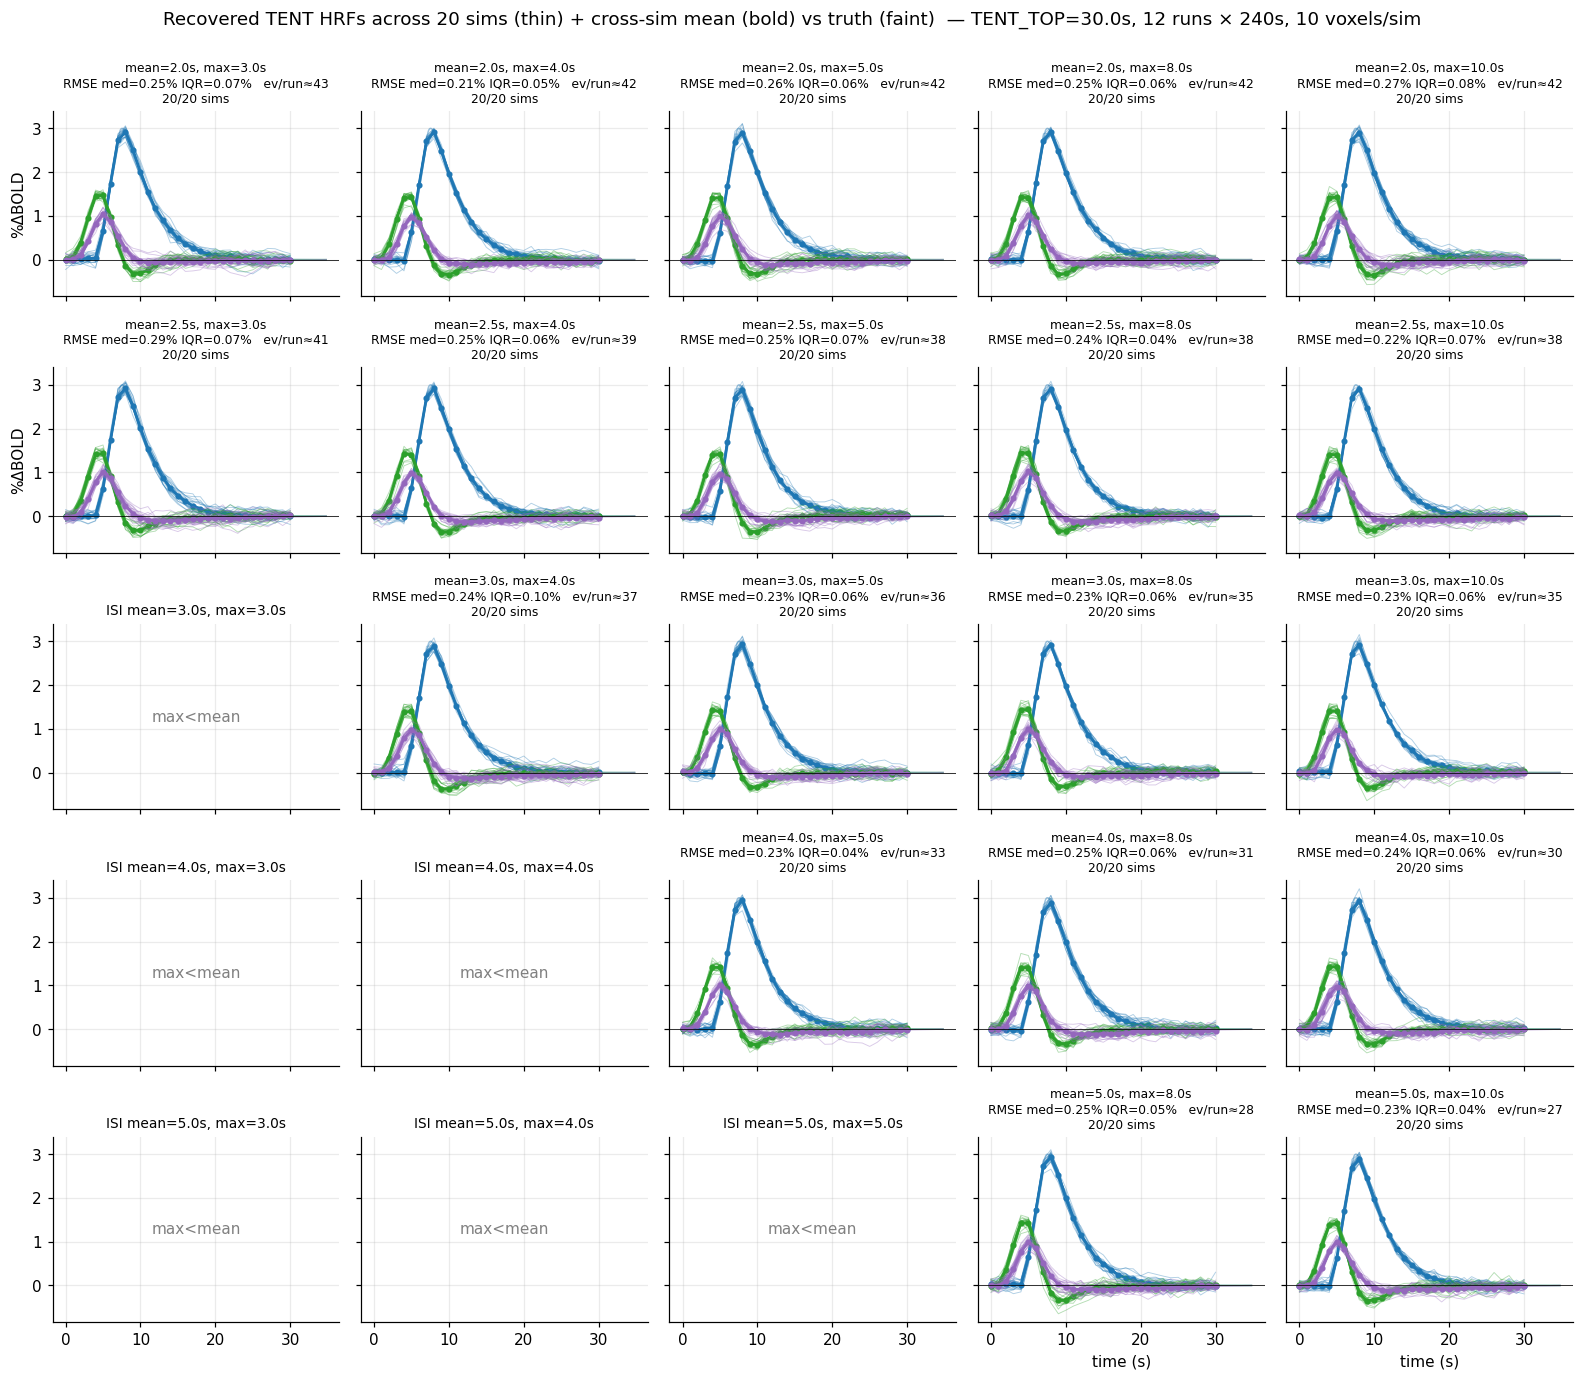

In [269]:
n_rows = len(SWEEP_ISI_MEANS); n_cols = len(SWEEP_ISI_MAXES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.9 * n_cols, 2.5 * n_rows), sharex='col', sharey=True)
for i, isi_m in enumerate(SWEEP_ISI_MEANS):
    for j, isi_x in enumerate(SWEEP_ISI_MAXES):
        ax = axes[i, j]
        if (i, j) not in results_grid:
            label = status_grid[i, j].strip() or 'failed'
            ax.text(0.5, 0.5, f'{label}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='0.5')
            ax.set_title(f'ISI mean={isi_m}s, max={isi_x}s', fontsize=9)
            continue
        out = results_grid[(i, j)]
        kt = out['knot_times']
        per_sim_mean_b = out['per_sim_mean_b']      # (n_sims_ok, n_cond, n_basis)
        sim_mean = per_sim_mean_b.mean(axis=0)      # cross-sim mean
        for c in range(n_cond):
            # truth (faint bold)
            ax.plot(t_eff_hi, amps[c] * eff_resp_hi[c], color=cond_colors[c], lw=1.0, alpha=0.45)
            # one thin line per simulation -- each is the (mean across voxels) for that sim
            for s_idx in range(per_sim_mean_b.shape[0]):
                ax.plot(kt, per_sim_mean_b[s_idx, c], color=cond_colors[c], lw=0.6, alpha=0.35)
            # bold mean across sims
            ax.plot(kt, sim_mean[c], 'o-', color=cond_colors[c], lw=1.8, ms=3)
        ax.axhline(0, color='k', lw=0.5)
        med = np.median(out['per_sim_rmse_sum'])
        iqr = np.percentile(out['per_sim_rmse_sum'], 75) - np.percentile(out['per_sim_rmse_sum'], 25)
        ev_per_run = out['per_sim_events_total'].mean() / N_RUNS
        ax.set_title(
            f'mean={isi_m}s, max={isi_x}s\n'
            f'RMSE med={med:.2f}% IQR={iqr:.2f}%   ev/run≈{ev_per_run:.0f}\n'
            f'{out["n_sims_ok"]}/{N_SIMS} sims',
            fontsize=8,
        )
        if i == n_rows - 1:
            ax.set_xlabel('time (s)')
        if j == 0:
            ax.set_ylabel('%ΔBOLD')
plt.suptitle(f'Recovered TENT HRFs across {N_SIMS} sims (thin) + cross-sim mean (bold) vs truth (faint)  '
             f'— TENT_TOP={TENT_TOP}s, {N_RUNS} runs × {RUN_DURATION:.0f}s, {N_VOXELS} voxels/sim', y=1.0)
plt.tight_layout(); plt.show()

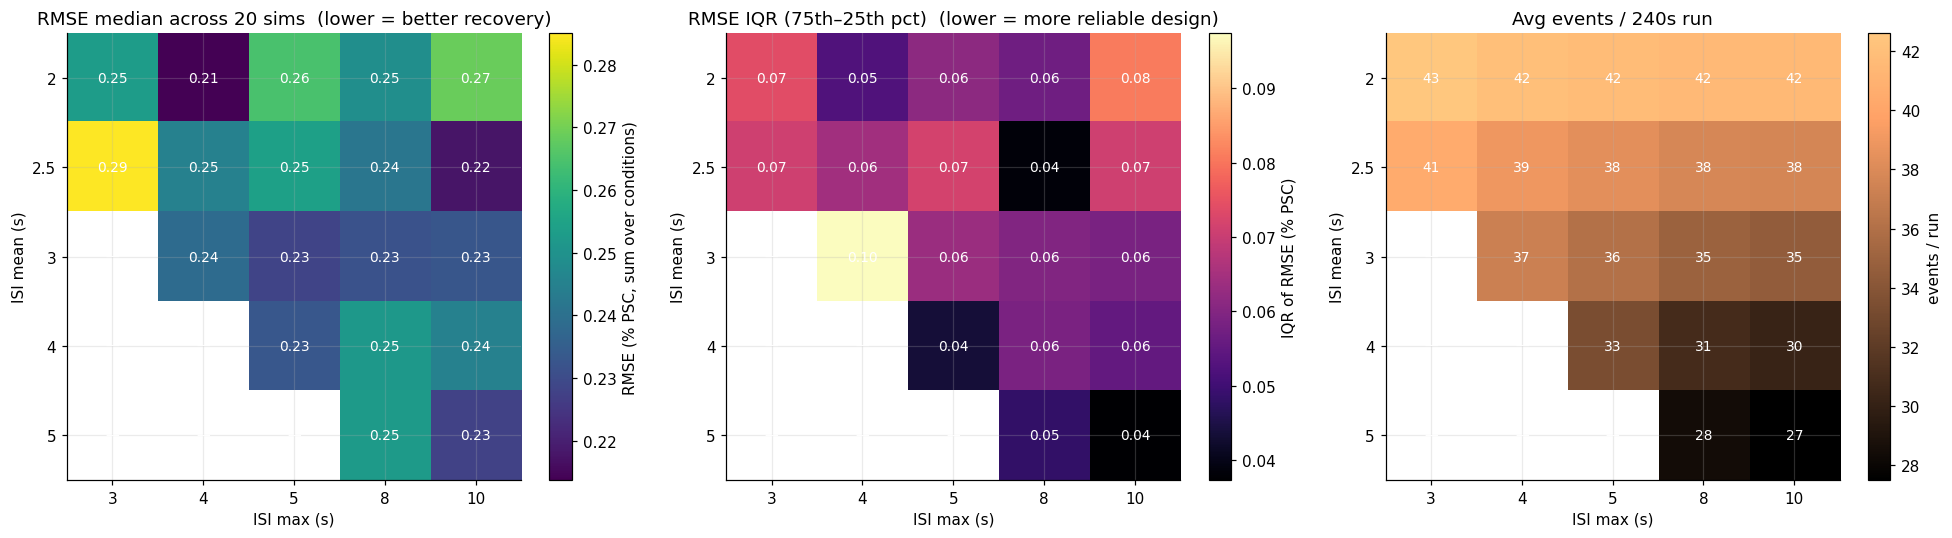

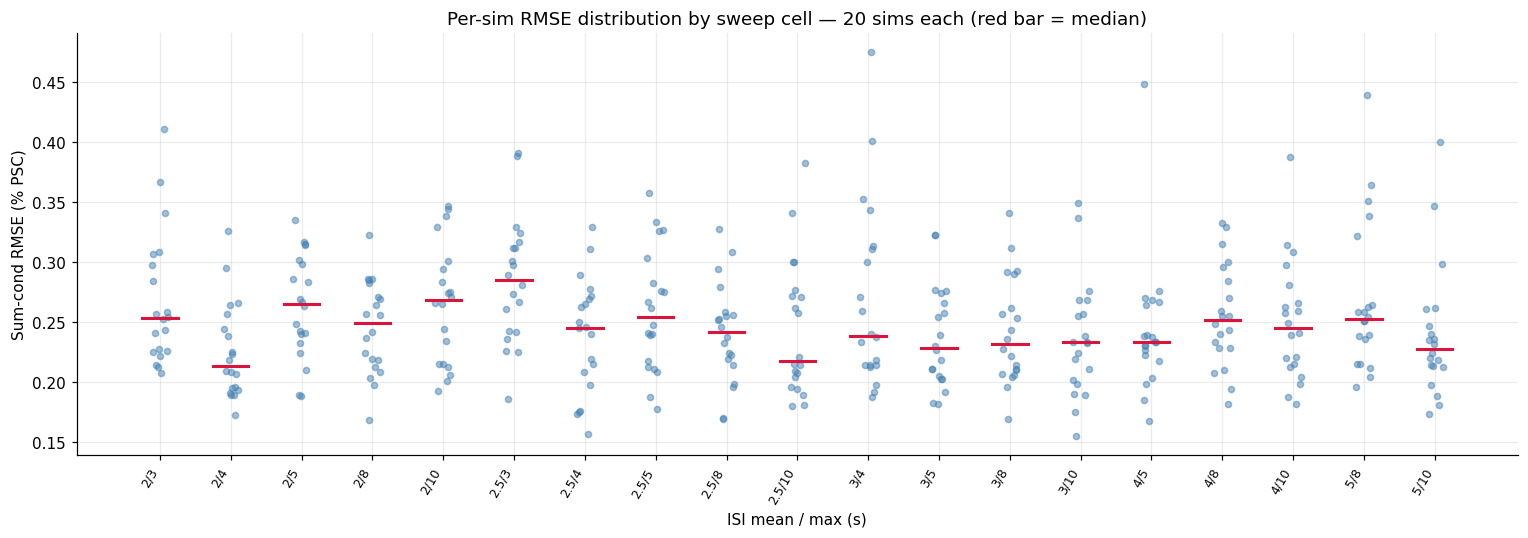

In [270]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def _annotate_heatmap(ax, M, fmt='{:.2f}'):
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            ax.text(j, i, '—' if np.isnan(v) else fmt.format(v),
                    ha='center', va='center', color='w', fontsize=9)

ax = axes[0]
im = ax.imshow(rmse_median, origin='upper', aspect='auto', cmap='viridis')
ax.set_xticks(range(len(SWEEP_ISI_MAXES))); ax.set_xticklabels([f'{t:g}' for t in SWEEP_ISI_MAXES])
ax.set_yticks(range(len(SWEEP_ISI_MEANS))); ax.set_yticklabels([f'{m:g}' for m in SWEEP_ISI_MEANS])
ax.set_xlabel('ISI max (s)'); ax.set_ylabel('ISI mean (s)')
ax.set_title(f'RMSE median across {N_SIMS} sims  (lower = better recovery)')
_annotate_heatmap(ax, rmse_median)
plt.colorbar(im, ax=ax, label='RMSE (% PSC, sum over conditions)')

ax = axes[1]
im2 = ax.imshow(rmse_iqr, origin='upper', aspect='auto', cmap='magma')
ax.set_xticks(range(len(SWEEP_ISI_MAXES))); ax.set_xticklabels([f'{t:g}' for t in SWEEP_ISI_MAXES])
ax.set_yticks(range(len(SWEEP_ISI_MEANS))); ax.set_yticklabels([f'{m:g}' for m in SWEEP_ISI_MEANS])
ax.set_xlabel('ISI max (s)'); ax.set_ylabel('ISI mean (s)')
ax.set_title(f'RMSE IQR (75th–25th pct)  (lower = more reliable design)')
_annotate_heatmap(ax, rmse_iqr)
plt.colorbar(im2, ax=ax, label='IQR of RMSE (% PSC)')

ax = axes[2]
im3 = ax.imshow(nev_mean, origin='upper', aspect='auto', cmap='copper')
ax.set_xticks(range(len(SWEEP_ISI_MAXES))); ax.set_xticklabels([f'{t:g}' for t in SWEEP_ISI_MAXES])
ax.set_yticks(range(len(SWEEP_ISI_MEANS))); ax.set_yticklabels([f'{m:g}' for m in SWEEP_ISI_MEANS])
ax.set_xlabel('ISI max (s)'); ax.set_ylabel('ISI mean (s)')
ax.set_title(f'Avg events / {RUN_DURATION:.0f}s run')
_annotate_heatmap(ax, nev_mean, fmt='{:.0f}')
plt.colorbar(im3, ax=ax, label='events / run')

plt.tight_layout(); plt.show()

# Per-cell strip plot of sum-cond RMSE distribution across sims -- shows the spread directly,
# not just a median/IQR summary. Cells with tightly clustered points are reliable; cells with
# wide scatter mean different onset draws give very different recovery quality.
fig, ax = plt.subplots(figsize=(14, 5))
positions = []
labels = []
data_cols = []
pos = 0
for i, isi_m in enumerate(SWEEP_ISI_MEANS):
    for j, isi_x in enumerate(SWEEP_ISI_MAXES):
        if (i, j) not in results_grid:
            continue
        data_cols.append(results_grid[(i, j)]['per_sim_rmse_sum'])
        positions.append(pos)
        labels.append(f'{isi_m:g}/{isi_x:g}')
        pos += 1
for p, vals in zip(positions, data_cols):
    ax.plot(np.full_like(vals, p, dtype=float) + np.random.uniform(-0.12, 0.12, len(vals)),
            vals, 'o', alpha=0.5, ms=4, color='steelblue')
    ax.plot([p - 0.25, p + 0.25], [np.median(vals)] * 2, color='crimson', lw=2)
ax.set_xticks(positions); ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=8)
ax.set_xlabel('ISI mean / max (s)'); ax.set_ylabel('Sum-cond RMSE (% PSC)')
ax.set_title(f'Per-sim RMSE distribution by sweep cell — {N_SIMS} sims each (red bar = median)')
plt.tight_layout(); plt.show()

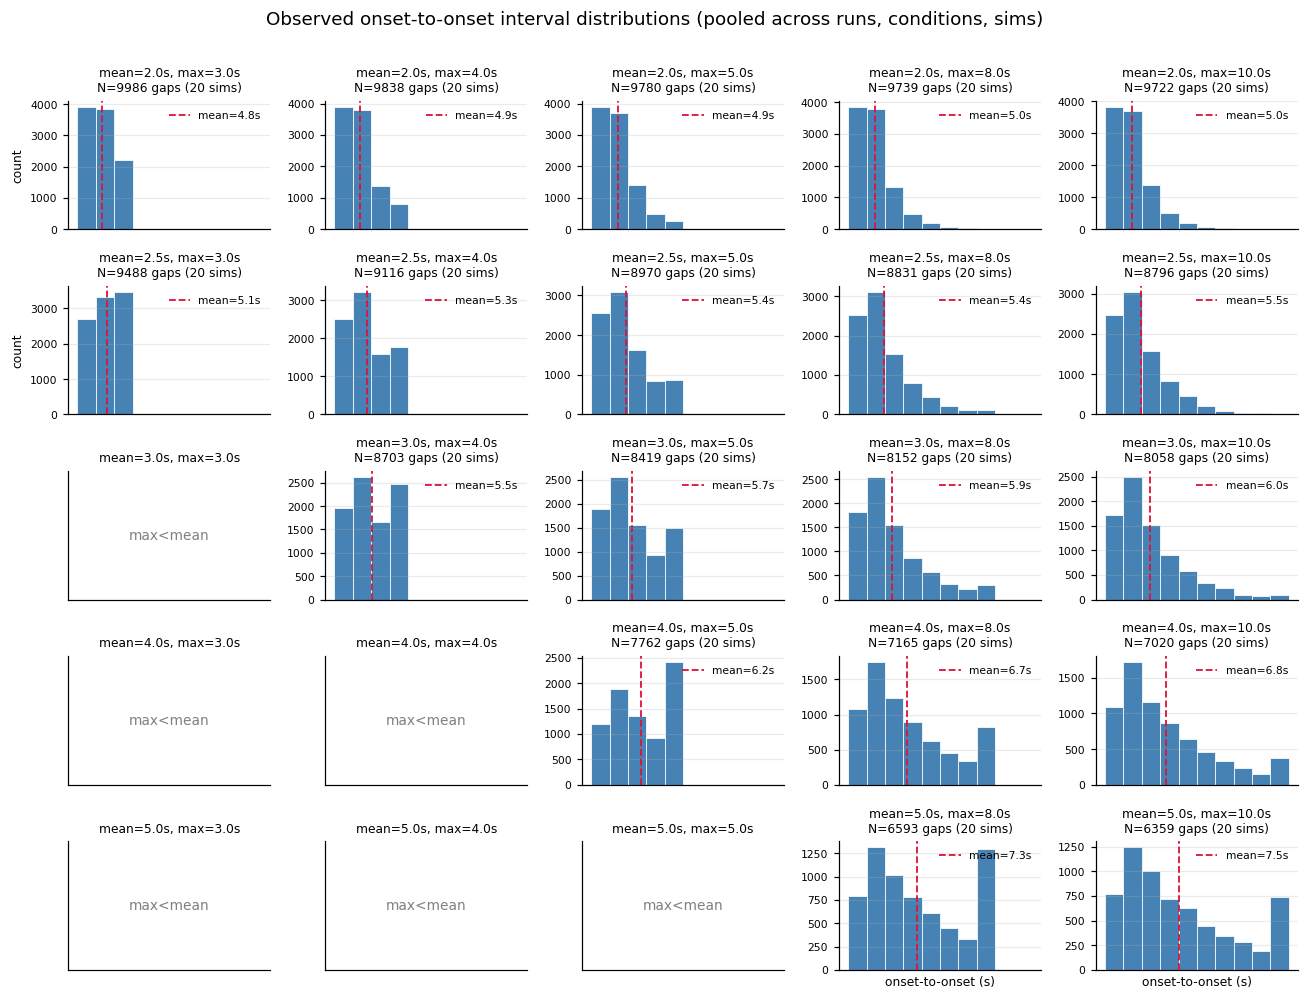

In [271]:
# ISI histograms: one tiny panel per sweep cell, same layout as the recovery grid.
# Pools onset-to-onset diffs across all runs, all conditions, and all N_SIMS sims so
# you see the underlying ISI distribution accurately.

n_rows = len(SWEEP_ISI_MEANS); n_cols = len(SWEEP_ISI_MAXES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 1.8 * n_rows),
                         sharex=True, sharey=False)
for i, isi_m in enumerate(SWEEP_ISI_MEANS):
    for j, isi_x in enumerate(SWEEP_ISI_MAXES):
        ax = axes[i, j]
        if (i, j) not in results_grid:
            ax.text(0.5, 0.5, status_grid[i, j].strip() or '—',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=9, color='0.5')
            ax.set_title(f'mean={isi_m}s, max={isi_x}s', fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        out = results_grid[(i, j)]
        diffs_all = []
        for sim_onsets in out['per_sim_onsets_all']:
            for run_onsets in sim_onsets:
                t_all = np.sort(np.concatenate(run_onsets))
                if len(t_all) > 1:
                    diffs_all.append(np.diff(t_all))
        diffs_all = np.concatenate(diffs_all) if diffs_all else np.array([])
        if diffs_all.size:
            lo = int(np.floor(diffs_all.min()))
            hi = int(np.ceil(diffs_all.max()))
            edges = np.arange(lo - 0.5, hi + 1.5, TR)
            ax.hist(diffs_all, bins=edges, color='steelblue', edgecolor='white', lw=0.5)
            ax.axvline(diffs_all.mean(), color='crimson', lw=1.2, ls='--',
                       label=f'mean={diffs_all.mean():.1f}s')
            ax.legend(fontsize=7, loc='upper right', frameon=False)
        ax.set_title(f'mean={isi_m}s, max={isi_x}s\nN={diffs_all.size} gaps ({out["n_sims_ok"]} sims)', fontsize=8)
        if i == n_rows - 1:
            ax.set_xlabel('onset-to-onset (s)', fontsize=8)
        if j == 0:
            ax.set_ylabel('count', fontsize=8)
        ax.tick_params(labelsize=7)
plt.suptitle('Observed onset-to-onset interval distributions (pooled across runs, conditions, sims)', y=1.005)
plt.tight_layout(); plt.show()

## 8. What to look for

With `TENT_TOP=30` fixed (long enough to capture the full per-onset response), the recovery floor is set by **how often events overlap inside the 30 s window**.

- **Top-left (short mean, tight max)**: events are densely packed and the ceiling stops you from getting any clean-baseline gaps. Tail of the recovered HRF should be biased / oscillatory.
- **Bottom-right (long mean, loose max)**: lots of clean-baseline gaps → tails recover faithfully. Fewer events per run though, so variance grows; watch the SD bands.
- **Same column, varying mean**: shows how *average* density matters even with a fixed cap.
- **Same row, varying max**: shows how the *upper tail* of the ISI distribution matters — even a few long gaps anchor the tail.

Knobs to play with next:
- Push `NOISE_PSC` up to see how the contamination floor moves.
- Move `CONDITIONS` HRFs further apart (later peaks → harder).
- Lower `TENT_TOP` if you want to flip back to the window-vs-ISI tradeoff.